## Cross-validation

Used to estimate how accurately a predictive model will perform in practice.

In [1]:
import sys
print(sys.executable)

# general python modules for scientific analysis
import sys, pathlib, os, itertools
import numpy as np
import pandas as pd
import matplotlib.pylab as plt

sys.path.append('../../src')
from sklearn.model_selection import train_test_split
from physion.analysis.read_NWB import Data
from physion.analysis.dataframe import NWB_to_dataframe, extract_stim_keys
from physion.utils import plot_tools as pt

sys.path.append('../../src/physion/analysis')
from cross_validation import TwoFold_train_test_split_basic
from cross_validation import TwoFold_train_test_split


C:\Users\laura.gonzalez\AppData\Local\miniforge3\python.exe


In [2]:
datafolder = os.path.join(os.path.expanduser('~'), 'DATA', 'In_Vivo_experiments','NDNF-WT-Dec-2022','NWBs')
filename = os.path.join(datafolder, '2022_12_14-13-27-41.nwb') #for example
data = Data(filename)
df = NWB_to_dataframe(filename,
                      normalize=['dFoF', 'Pupil-diameter', 'Running-Speed', 'Whisking'],
                      visual_stim_label='per-protocol-and-parameters',
                      verbose=False)

NWB-file reading time: 915.4ms


protocols: ['moving-dots' 'random-dots' 'static-patch' 'looming-stim'
 'Natural-Images-4-repeats' 'grey-10min' 'drifting-gratings']
 [!!] need to explicit the "protocol_id" or "protocol_name" [!!] 
         ---->   set to protocol_id=0 by default 
 
 [!!] need to pass either a protocol_id or a protocol_name [!!] 



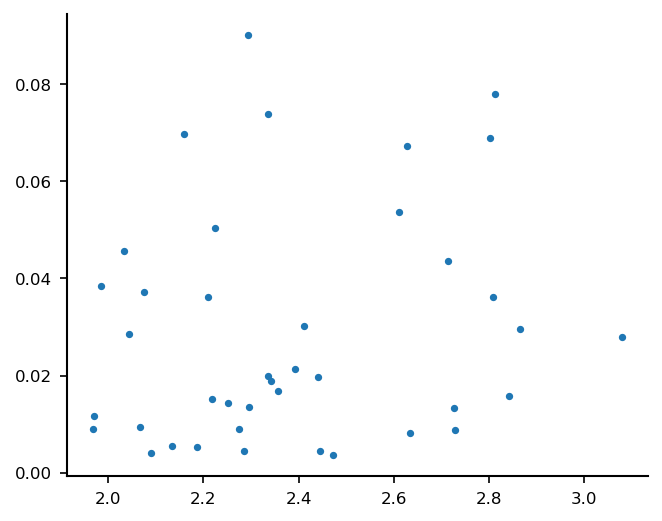

In [3]:
from physion.analysis.process_NWB import EpisodeData

def compute_high_movement_cond(behav_episodes,
                               running_speed_threshold):
    # HMcond: high movement condition
    if running_speed_threshold is not None:
        HMcond = (behav_episodes.running_speed.mean(axis=1)>running_speed_threshold) 
    return HMcond

behav_episodes = EpisodeData(data, 
                             quantities=['Pupil', 'Running-Speed'],
                             #protocol_name=protocol,
                             prestim_duration=0,
                             verbose=False)
        
# HMcond: high movement condition
HMcond = compute_high_movement_cond(behav_episodes, running_speed_threshold=0.1)
fig = plt.figure(figsize=(5, 4))
plt.plot(behav_episodes.pupil_diameter.mean(axis=1)[~HMcond],
        behav_episodes.running_speed.mean(axis=1)[~HMcond], 'o', color='tab:blue')
plt.plot(behav_episodes.pupil_diameter.mean(axis=1)[HMcond],
        behav_episodes.running_speed.mean(axis=1)[HMcond], 'o', color='tab:orange')


[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 16. 17. 18.
 19.]


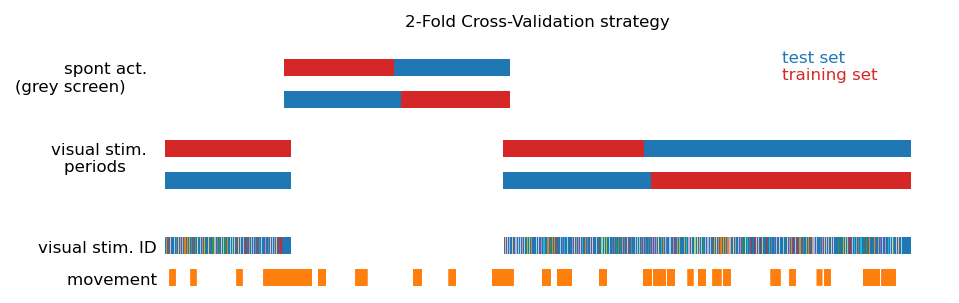

In [4]:
cvIndices = TwoFold_train_test_split_basic(df, spont_act_key='VisStim_grey-10min')
#print(cvIndices)

# Plot
fig, ax = plt.subplots(figsize=(7,2))
ii = 13

#spontaneous
for train, test in zip(cvIndices['spont_train_sets'], cvIndices['spont_test_sets']):
    ax.scatter(df['time'][train], ii+0.5+np.zeros(len(df['time'][train])), c='tab:red', marker="_", lw=8)
    ax.scatter(df['time'][test], ii+0.5+np.zeros(len(df['time'][test])), c='tab:blue', marker="_", lw=8)
    ii-=2
ax.annotate('spont act.    \n(grey screen)        ', (0, ii+3), ha='right')
ii-=1

#evoked
for train, test in zip(cvIndices['stim_train_sets'], cvIndices['stim_test_sets']):
    
    ax.scatter(df['time'][train], ii+0.5+np.zeros(len(df['time'][train])), c='tab:red', marker="_", lw=8)
    ax.scatter(df['time'][test] , ii+0.5+np.zeros(len(df['time'][test])),  c='tab:blue',marker="_", lw=8)
    ii-=2
ax.annotate('visual stim.    \nperiods        ', (0, ii+3), ha='right')
ii-=1

#stim id
stim_keys = [k for k in df if ('VisStim' in k)]
stimID = 0*df['time']
stim_cond = (~df['VisStim_grey-10min'])

for i, k in enumerate(stim_keys):
        stimID[df[k]] = i+1
        #print(stimID[df[k]])
print(np.unique(stimID[stim_cond]))
ax.scatter(df['time'][stim_cond], [ii-0.5] * np.sum(stim_cond), c=stimID[stim_cond], marker="_", lw=8, cmap=plt.cm.tab20)
ax.annotate('visual stim. ID  ', (0, ii-1), ha='right')
ii-=3

#movement
running_dFoF_sampled = data.build_running_speed(specific_time_sampling=df['time'].values)  
speed_bool = pd.Series((running_dFoF_sampled >= 0.60).astype(int)) 
ax.scatter(x = df['time'][speed_bool == 1], 
           y = ii + speed_bool[speed_bool == 1] - 0.5, 
           c='tab:orange', 
           marker="_", 
           lw=8, 
           label="Above Threshold")
ax.annotate('movement  ', (0, ii), ha='right')

#final arangements
ax.annotate('training set', (.8,.9), color='tab:red', xycoords='axes fraction')
ax.annotate('test set\n', (.8,.9), color='tab:blue', xycoords='axes fraction')
ax.axis('off')
ax.set_xlabel("time (s)")
ax.set_title('2-Fold Cross-Validation strategy\n ')
ax.axes.get_xaxis().set_visible(True)

Check how many movement and quiet there is in training and test set 

In [5]:
#2 different state (moving vs quiet)
print(len(np.unique(speed_bool)))

2


In [6]:
running_dFoF_sampled = data.build_running_speed(specific_time_sampling=df['time'].values)

for i in range(2):
    print(f"{i} CV")
    for subset in cvIndices.keys():
        speed_bool = pd.Series((running_dFoF_sampled >= 0.10).astype(int))[cvIndices[subset][i]]
        print(f"In the subset {subset}, there is {sum(speed_bool)} moments moving out of {len(speed_bool)}")
        

0 CV
In the subset spont_train_sets, there is 1595 moments moving out of 8827
In the subset spont_test_sets, there is 1942 moments moving out of 8827
In the subset stim_train_sets, there is 3055 moments moving out of 20954
In the subset stim_test_sets, there is 4041 moments moving out of 20954
1 CV
In the subset spont_train_sets, there is 1942 moments moving out of 8827
In the subset spont_test_sets, there is 1595 moments moving out of 8827
In the subset stim_train_sets, there is 4041 moments moving out of 20954
In the subset stim_test_sets, there is 3055 moments moving out of 20954


Check composition of stimuli in training and test sets.

In [7]:
#19 different stimuli
print(np.unique(stim_keys))


['VisStim_Natural-Images-4-repeats--Image-ID_1.0'
 'VisStim_Natural-Images-4-repeats--Image-ID_2.0'
 'VisStim_Natural-Images-4-repeats--Image-ID_3.0'
 'VisStim_Natural-Images-4-repeats--Image-ID_4.0'
 'VisStim_Natural-Images-4-repeats--Image-ID_5.0'
 'VisStim_drifting-gratings--angle_0.0'
 'VisStim_drifting-gratings--angle_180.0'
 'VisStim_drifting-gratings--angle_270.0'
 'VisStim_drifting-gratings--angle_90.0' 'VisStim_grey-10min'
 'VisStim_looming-stim' 'VisStim_moving-dots--speed_60.0'
 'VisStim_moving-dots--speed_90.0' 'VisStim_random-dots--seed_1'
 'VisStim_random-dots--seed_2' 'VisStim_random-dots--seed_3'
 'VisStim_random-dots--seed_4' 'VisStim_static-patch--angle_0.0'
 'VisStim_static-patch--angle_90.0']


In [8]:
cvIndices = TwoFold_train_test_split(filename, data, df, spont_act_key='VisStim_grey-10min')
sets = ['stim_train_sets', 'stim_test_sets']
keys = np.unique(stim_keys)
final = []

for i in range(2):
    print(f'\n CV fold {i}')
    for my_set in sets:
        subset = df[cvIndices[my_set][i][0]:cvIndices[my_set][i][-1]]
        for key in keys:
            stim_cond = (subset[key])
            final.append(np.sum(stim_cond))
            print(f'There is {np.sum(stim_cond)} stimulus {key}')

    #for j in range(len(keys)):
    #    print(f'\nStimulus {keys[j]} :\n {final[j]} in {sets[0]} and {final[j*2]} in {sets[1]}')    


Fold 1 (Spontaneous Activity):
  Training (8827) - Running: 191, Non-Running: 8636
  Test (8827) - Running: 191, Non-Running: 8636

Fold 1 (Stimulus-Evoked Activity):
  Training (20954) - Running: 246, Non-Running: 20708
  Test (20954) - Running: 246, Non-Running: 20708

Fold 2 (Spontaneous Activity):
  Training (8827) - Running: 191, Non-Running: 8636
  Test (8827) - Running: 191, Non-Running: 8636

Fold 2 (Stimulus-Evoked Activity):
  Training (20954) - Running: 246, Non-Running: 20708
  Test (20954) - Running: 246, Non-Running: 20708

 CV fold 0
There is 589 stimulus VisStim_Natural-Images-4-repeats--Image-ID_1.0
There is 528 stimulus VisStim_Natural-Images-4-repeats--Image-ID_2.0
There is 589 stimulus VisStim_Natural-Images-4-repeats--Image-ID_3.0
There is 704 stimulus VisStim_Natural-Images-4-repeats--Image-ID_4.0
There is 590 stimulus VisStim_Natural-Images-4-repeats--Image-ID_5.0
There is 352 stimulus VisStim_drifting-gratings--angle_0.0
There is 264 stimulus VisStim_drifting-g


Fold 1
spont_train_sets (8827)
 Running 1595 Non-running 7232
spont_test_sets (8827)
 Running 1942 Non-running 6885
stim_train_sets (20954)
 Running 3055 Non-running 17899
stim_test_sets (20954)
 Running 4041 Non-running 16913

Fold 2
spont_train_sets (8827)
 Running 1942 Non-running 6885
spont_test_sets (8827)
 Running 1595 Non-running 7232
stim_train_sets (20954)
 Running 4041 Non-running 16913
stim_test_sets (20954)
 Running 3055 Non-running 17899


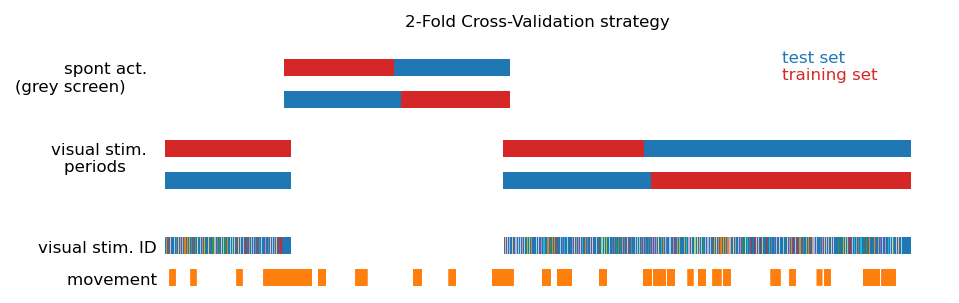

In [16]:
cvIndices = TwoFold_train_test_split_basic( df, spont_act_key='VisStim_grey-10min')
#print(cvIndices)

# Plot
fig, ax = plt.subplots(figsize=(7,2))
ii = 13

#spontaneous
for train, test in zip(cvIndices['spont_train_sets'], cvIndices['spont_test_sets']):
    ax.scatter(df['time'][train], ii+0.5+np.zeros(len(df['time'][train])), c='tab:red', marker="_", lw=8)
    ax.scatter(df['time'][test], ii+0.5+np.zeros(len(df['time'][test])), c='tab:blue', marker="_", lw=8)
    ii-=2
ax.annotate('spont act.    \n(grey screen)        ', (0, ii+3), ha='right')
ii-=1

#evoked
for train, test in zip(cvIndices['stim_train_sets'], cvIndices['stim_test_sets']):
    
    ax.scatter(df['time'][train], ii+0.5+np.zeros(len(df['time'][train])), c='tab:red', marker="_", lw=8)
    ax.scatter(df['time'][test] , ii+0.5+np.zeros(len(df['time'][test])),  c='tab:blue',marker="_", lw=8)
    ii-=2
ax.annotate('visual stim.    \nperiods        ', (0, ii+3), ha='right')
ii-=1

#stim id
stim_keys = [k for k in df if ('VisStim' in k)]
stimID = 0*df['time']
stim_cond = (~df['VisStim_grey-10min'])

for i, k in enumerate(stim_keys):
        stimID[df[k]] = i+1
        #print(stimID[df[k]])
#print(np.unique(stimID[stim_cond]))
ax.scatter(df['time'][stim_cond], [ii-0.5] * np.sum(stim_cond), c=stimID[stim_cond], marker="_", lw=8, cmap=plt.cm.tab20)
ax.annotate('visual stim. ID  ', (0, ii-1), ha='right')
ii-=3

#movement
running_dFoF_sampled = data.build_running_speed(specific_time_sampling=df['time'].values)  
speed_bool = pd.Series((running_dFoF_sampled >= 0.60).astype(int)) 
ax.scatter(x = df['time'][speed_bool == 1], 
           y = ii + speed_bool[speed_bool == 1] - 0.5, 
           c='tab:orange', 
           marker="_", 
           lw=8, 
           label="Above Threshold")
ax.annotate('movement  ', (0, ii), ha='right')

#final arangements
ax.annotate('training set', (.8,.9), color='tab:red', xycoords='axes fraction')
ax.annotate('test set\n', (.8,.9), color='tab:blue', xycoords='axes fraction')
ax.axis('off')
ax.set_xlabel("time (s)")
ax.set_title('2-Fold Cross-Validation strategy\n ')
ax.axes.get_xaxis().set_visible(True)

running_dFoF_sampled = data.build_running_speed(specific_time_sampling=df['time'].values)

# Debugging: Print the number of running/not running instances
for i in range(2):
    print(f"\nFold {i + 1}")
    for subset in cvIndices.keys():
        speed_bool = pd.Series((running_dFoF_sampled >= 0.10).astype(int))[cvIndices[subset][i]]
        print(f"{subset} ({len(speed_bool)})\n Running {sum(speed_bool)} Non-running {len(speed_bool)- sum(speed_bool) }")



Fold 1 (Spontaneous Activity):
  Training (8827) - Running: 191, Non-Running: 8636
  Test (8827) - Running: 191, Non-Running: 8636

Fold 1 (Stimulus-Evoked Activity):
  Training (20954) - Running: 246, Non-Running: 20708
  Test (20954) - Running: 246, Non-Running: 20708

Fold 2 (Spontaneous Activity):
  Training (8827) - Running: 191, Non-Running: 8636
  Test (8827) - Running: 191, Non-Running: 8636

Fold 2 (Stimulus-Evoked Activity):
  Training (20954) - Running: 246, Non-Running: 20708
  Test (20954) - Running: 246, Non-Running: 20708

Fold 1
spont_train_sets (8827)
 Running 1543 Non-running 7284
spont_test_sets (8827)
 Running 1994 Non-running 6833
stim_train_sets (20954)
 Running 3062 Non-running 17892
stim_test_sets (20954)
 Running 4034 Non-running 16920

Fold 2
spont_train_sets (8827)
 Running 1994 Non-running 6833
spont_test_sets (8827)
 Running 1543 Non-running 7284
stim_train_sets (20954)
 Running 4034 Non-running 16920
stim_test_sets (20954)
 Running 3062 Non-running 17892


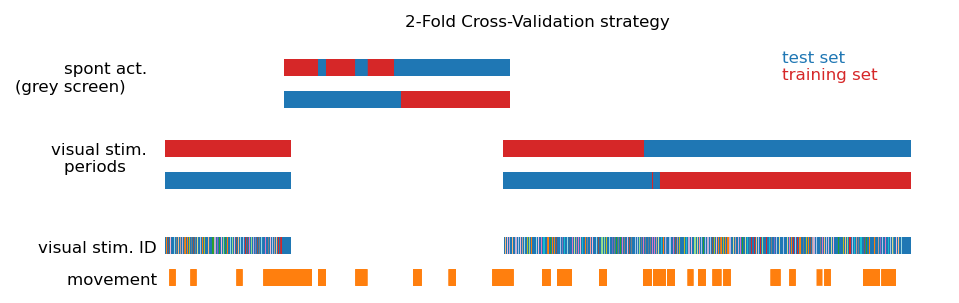

In [17]:
cvIndices = TwoFold_train_test_split(filename, data, df, spont_act_key='VisStim_grey-10min')
#print(cvIndices)

# Plot
fig, ax = plt.subplots(figsize=(7,2))
ii = 13

#spontaneous
for train, test in zip(cvIndices['spont_train_sets'], cvIndices['spont_test_sets']):
    ax.scatter(df['time'][train], ii+0.5+np.zeros(len(df['time'][train])), c='tab:red', marker="_", lw=8)
    ax.scatter(df['time'][test], ii+0.5+np.zeros(len(df['time'][test])), c='tab:blue', marker="_", lw=8)
    ii-=2
ax.annotate('spont act.    \n(grey screen)        ', (0, ii+3), ha='right')
ii-=1

#evoked
for train, test in zip(cvIndices['stim_train_sets'], cvIndices['stim_test_sets']):
    
    ax.scatter(df['time'][train], ii+0.5+np.zeros(len(df['time'][train])), c='tab:red', marker="_", lw=8)
    ax.scatter(df['time'][test] , ii+0.5+np.zeros(len(df['time'][test])),  c='tab:blue',marker="_", lw=8)
    ii-=2
ax.annotate('visual stim.    \nperiods        ', (0, ii+3), ha='right')
ii-=1

#stim id
stim_keys = [k for k in df if ('VisStim' in k)]
stimID = 0*df['time']
stim_cond = (~df['VisStim_grey-10min'])

for i, k in enumerate(stim_keys):
        stimID[df[k]] = i+1
        #print(stimID[df[k]])
#print(np.unique(stimID[stim_cond]))
ax.scatter(df['time'][stim_cond], [ii-0.5] * np.sum(stim_cond), c=stimID[stim_cond], marker="_", lw=8, cmap=plt.cm.tab20)
ax.annotate('visual stim. ID  ', (0, ii-1), ha='right')
ii-=3

#movement
running_dFoF_sampled = data.build_running_speed(specific_time_sampling=df['time'].values)  
speed_bool = pd.Series((running_dFoF_sampled >= 0.60).astype(int)) 
ax.scatter(x = df['time'][speed_bool == 1], 
           y = ii + speed_bool[speed_bool == 1] - 0.5, 
           c='tab:orange', 
           marker="_", 
           lw=8, 
           label="Above Threshold")
ax.annotate('movement  ', (0, ii), ha='right')

#final arangements
ax.annotate('training set', (.8,.9), color='tab:red', xycoords='axes fraction')
ax.annotate('test set\n', (.8,.9), color='tab:blue', xycoords='axes fraction')
ax.axis('off')
ax.set_xlabel("time (s)")
ax.set_title('2-Fold Cross-Validation strategy\n ')
ax.axes.get_xaxis().set_visible(True)

running_dFoF_sampled = data.build_running_speed(specific_time_sampling=df['time'].values)

# Debugging: Print the number of running/not running instances
for i in range(2):
    print(f"\nFold {i + 1}")
    for subset in cvIndices.keys():
        speed_bool = pd.Series((running_dFoF_sampled >= 0.10).astype(int))[cvIndices[subset][i]]
        print(f"{subset} ({len(speed_bool)})\n Running {sum(speed_bool)} Non-running {len(speed_bool)- sum(speed_bool) }")
